# DATA 266 Lab 1 — Task 3: CycleGAN, photo ↔ Monet
**Member:** Rajesh Paruchuri · **Data:** class Kaggle competition images (`monet_jpg/` = domain A, `photo_jpg/` = domain B)

Two generators (G_AB: Monet→photo, G_BA: photo→Monet, the Kaggle direction) and two PatchGAN discriminators,
written from scratch in `cyclegan.py`. No pretrained network touches training or generation. Inception-v3, VGG16 and
LPIPS appear only in `evaluate.py`, to *measure* images the CycleGAN has already produced.

Run (repo root): `jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=-1 task3_gan/rajesh_paruchuri/src/part3_cyclegan.ipynb`
· smoke test: prefix with `LAB_SMOKE=1`.

In [1]:
import json, sys, time, csv, subprocess
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path.cwd()) if (Path.cwd() / "cyclegan.py").exists() else str(Path.cwd() / "task3_gan/rajesh_paruchuri/src"))
import cyclegan as cg

P = cg.find_paths()
R = lambda p: cg.rel(p, P["repo"])
CFG = cg.load_config(P)
SMOKE = bool(CFG["smoke"])
TAG = "smoke" if SMOKE else "full"
device = cg.pick_device()
print("smoke:", SMOKE, "| seed:", CFG["seed"], "| device:", device, "|", cg.hardware_string(device))
import torchvision
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| python", sys.version.split()[0])

smoke: False | seed: 266 | device: mps | MPS (Apple GPU) on Apple M4


torch 2.11.0 | torchvision 0.26.0 | python 3.13.7


## 3.1 Data: two unpaired domains

domain A (Monet paintings): 300 | domain B (photos): 7038 | image sizes seen: {(256, 256)}
unpaired: there is no correspondence between any Monet file and any photo file


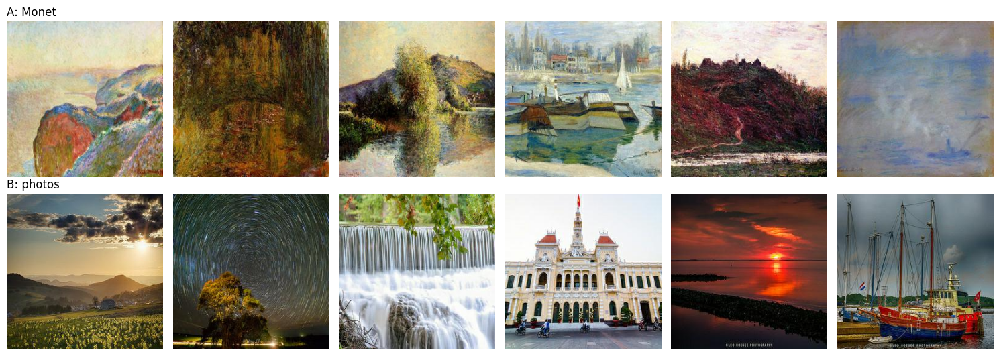

In [2]:
root = cg.data_dir(CFG, P)
monet, photo = cg.list_images(root / "monet_jpg"), cg.list_images(root / "photo_jpg")
sizes = {Image.open(p).size for p in monet[:50] + photo[:50]}
print("domain A (Monet paintings):", len(monet), "| domain B (photos):", len(photo), "| image sizes seen:", sizes)
print("unpaired: there is no correspondence between any Monet file and any photo file")
fig, ax = plt.subplots(2, 6, figsize=(15, 5.4))
for i in range(6):
    ax[0, i].imshow(Image.open(monet[i * 37 % len(monet)])); ax[0, i].axis("off")
    ax[1, i].imshow(Image.open(photo[i * 911 % len(photo)])); ax[1, i].axis("off")
ax[0, 0].set_title("A: Monet", loc="left"); ax[1, 0].set_title("B: photos", loc="left")
fig.tight_layout(); fig.savefig(P["out"] / f"domains_{TAG}.png", dpi=110); plt.show()

## 3.1 Model
| Part | My choice | Why |
|---|---|---|
| Generators (×2) | ResNet: c7s1-48 → 2 stride-2 downsamples → **6 residual blocks** → 2 × (bilinear ×2 + 3×3 conv) → c7s1-3, tanh; InstanceNorm, reflection padding | 6 blocks and 48 base channels (the standard CycleGAN uses 9 and 64) halve the cost on a laptop GPU. Resize+conv upsampling avoids the checkerboard artifacts of transposed convolutions |
| Discriminators (×2) | 70×70 PatchGAN C64-C128-C256-C512-1 with **spectral normalisation**, no norm layers | judges local texture, which is what style is. Spectral norm bounds D's Lipschitz constant and stabilises the min-max game |
| Adversarial loss | LSGAN (MSE to 1 / 0) | smoother gradients than the log loss when D is confident |
| Cycle loss | L1(G_BA(G_AB(a)), a) + L1(G_AB(G_BA(b)), b), λ = 10 | the constraint that makes unpaired training possible: a translation must be invertible |
| Identity loss | L1(G_BA(a), a) + L1(G_AB(b), b), λ = 5 | stops the generators from shifting colours that are already in the target domain |
| **DiffAugment** | colour + translation + cutout on every real *and* fake D input | only 300 Monet paintings, so without augmentation D memorises them and G gets useless gradients |
| Replay buffer | 50 past fakes | D sees a mix of old and new fakes, which reduces oscillation |
| **EMA generators** | decay 0.999, used for all outputs | averaging weights smooths GAN noise between steps |
| Training input | random **128×128 crops** + flips, batch 1 | about 4× cheaper than full images. The model is fully convolutional, so inference runs on full 256×256 images |
| Schedule | Adam 2e-4, β = (0.5, 0.999); 80 epochs × 300 iterations; constant for 40 epochs, then linear decay to 0 | the standard CycleGAN recipe |

In [3]:
G_AB, G_BA, D_A, D_B = cg.build_models(CFG, device)
print("G params each: {:,} | D params each: {:,} | total: {:,}".format(cg.count_params(G_AB), cg.count_params(D_A),
                                                                         cg.count_params(G_AB, G_BA, D_A, D_B)))
x = torch.randn(1, 3, 256, 256, device=device)
with torch.no_grad():
    print("G(256x256) ->", tuple(G_BA(x).shape), "| D(256x256) -> patch map", tuple(D_A(x).shape),
          "| D(128x128 crop) ->", tuple(D_A(x[..., :128, :128]).shape))
del G_AB, G_BA, D_A, D_B

G params each: 4,412,931 | D params each: 2,764,737 | total: 14,355,336


G(256x256) -> (1, 3, 256, 256) | D(256x256) -> patch map (1, 1, 30, 30) | D(128x128 crop) -> (1, 1, 14, 14)


## 3.1 Training
Training runs in its own process (`python cyclegan.py full`) and writes an unedited raw log to
`reproducibility/raw_logs/rajesh_paruchuri/task3_gan/`. If a finished checkpoint and history already exist, this
cell reuses them instead of retraining (delete them to retrain).

In [4]:
ckpt = P["ckpt"] / f"cyclegan_{TAG}.pt"
hist_path = P["out"] / f"train_history_{TAG}.json"
log_path = P["logs"] / f"train_{TAG}.log"
if not (ckpt.exists() and hist_path.exists()):
    run = subprocess.run([sys.executable, str(P["src"] / "cyclegan.py"), TAG], capture_output=True, text=True)
    print(run.stdout[-4000:])
    if run.returncode != 0:
        raise RuntimeError(run.stderr[-3000:])
else:
    print("reusing finished run:", R(ckpt))
lines = open(log_path).read().splitlines()
print("\n".join(lines[:4] + ["..."] + [l for l in lines if l.startswith("EPOCH")][-6:] + lines[-2:]))
H = json.load(open(hist_path))
hist, summary = H["hist"], H["summary"]

reusing finished run: task3_gan/rajesh_paruchuri/checkpoints/cyclegan_full.pt
run_start=2026-10-02 11:32:22 member=rajesh_paruchuri smoke=False
device=mps hardware=MPS (Apple GPU) on Apple M4 torch=2.11.0 python=3.13.7
n_monet=300 n_photo=7038 crop=128 batch=1 epochs=80 iters_per_epoch=300 total_iters=24000 decay_start_epoch=40
G params (each)=4412931 D params (each)=2764737 total=14355336 config={"ngf": 48, "n_blocks": 6, "ndf": 64, "lr": 0.0002, "betas": [0.5, 0.999], "lambda_cycle": 10.0, "lambda_identity": 5.0, "pool_size": 50, "diffaugment": true, "ema_decay": 0.999}
...
EPOCH 75/80 epoch_sec=124.2 img_per_sec=4.83 nan=0 peak_mps_tensor_mb=409
EPOCH 76/80 epoch_sec=127.5 img_per_sec=4.70 nan=0 peak_mps_tensor_mb=409
EPOCH 77/80 epoch_sec=130.0 img_per_sec=4.61 nan=0 peak_mps_tensor_mb=409
EPOCH 78/80 epoch_sec=145.4 img_per_sec=4.13 nan=0 peak_mps_tensor_mb=409
EPOCH 79/80 epoch_sec=120.1 img_per_sec=5.00 nan=0 peak_mps_tensor_mb=409
EPOCH 80/80 epoch_sec=125.8 img_per_sec=4.77 na

## 3.1 Training behaviour: convergence and stability
Each point is the mean over a 50-iteration window.

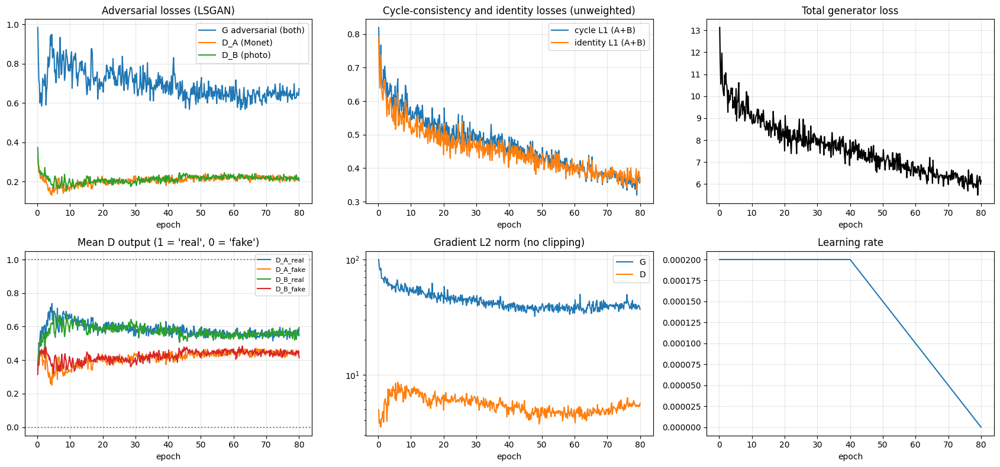

{'total_training_time_sec': 9417.23, 'train_loop_time_sec': 9398.991, 'iterations': 24000, 'epochs': 80, 'images_per_sec': 5.107, 'nan_count': 0, 'peak_mps_tensor_memory_mb': 408.887, 'peak_mps_driver_memory_mb': 1008.906, 'peak_process_rss_mb': 693.469, 'params_G_each': 4412931, 'params_D_each': 2764737, 'params_total': 14355336, 'grad_norm_G_mean': 44.2, 'grad_norm_G_max': 99.917, 'grad_norm_D_mean': 5.495, 'grad_norm_D_max': 8.581, 'hardware': 'MPS (Apple GPU) on Apple M4'}


In [5]:
it = np.array(hist["iter"]); ep = it / CFG["iters_per_epoch"] if not SMOKE else it / CFG["smoke_iters_per_epoch"]
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
ax[0, 0].plot(ep, hist["loss_G_adv"], label="G adversarial (both)"); ax[0, 0].plot(ep, hist["loss_D_A"], label="D_A (Monet)")
ax[0, 0].plot(ep, hist["loss_D_B"], label="D_B (photo)"); ax[0, 0].set(title="Adversarial losses (LSGAN)", xlabel="epoch"); ax[0, 0].legend()
ax[0, 1].plot(ep, hist["loss_cycle"], label="cycle L1 (A+B)"); ax[0, 1].plot(ep, hist["loss_identity"], label="identity L1 (A+B)")
ax[0, 1].set(title="Cycle-consistency and identity losses (unweighted)", xlabel="epoch"); ax[0, 1].legend()
ax[0, 2].plot(ep, hist["loss_G"], color="k"); ax[0, 2].set(title="Total generator loss", xlabel="epoch")
for k in ("D_A_real", "D_A_fake", "D_B_real", "D_B_fake"):
    ax[1, 0].plot(ep, hist[k], label=k)
ax[1, 0].axhline(1, ls=":", c="gray"); ax[1, 0].axhline(0, ls=":", c="gray")
ax[1, 0].set(title="Mean D output (1 = 'real', 0 = 'fake')", xlabel="epoch"); ax[1, 0].legend(fontsize=8)
ax[1, 1].plot(ep, hist["grad_norm_G"], label="G"); ax[1, 1].plot(ep, hist["grad_norm_D"], label="D")
ax[1, 1].set(title="Gradient L2 norm (no clipping)", xlabel="epoch", yscale="log"); ax[1, 1].legend()
ax[1, 2].plot(ep, hist["lr"]); ax[1, 2].set(title="Learning rate", xlabel="epoch")
for a in ax.flat:
    a.grid(alpha=.3)
fig.tight_layout(); fig.savefig(P["out"] / f"loss_curves_{TAG}.png", dpi=120); plt.show()
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in summary.items()})

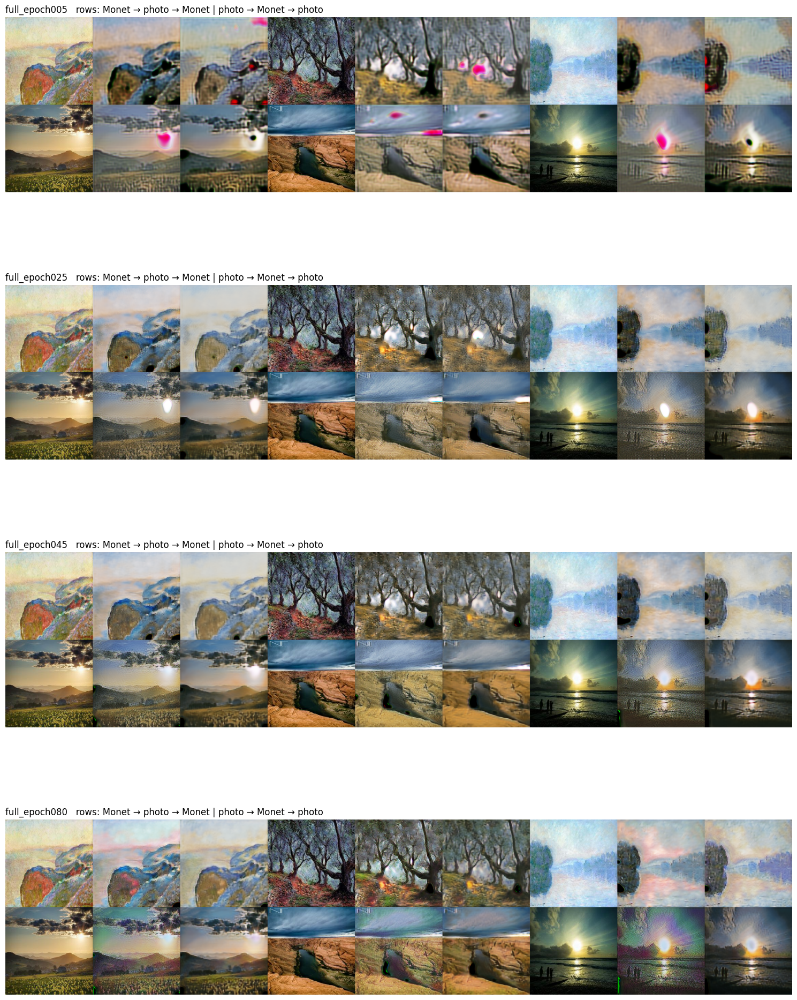

In [6]:
prev = sorted((P["out"] / "previews").glob(f"{TAG}_epoch*.png"))
show = [prev[i] for i in sorted({0, len(prev) // 4, len(prev) // 2, len(prev) - 1}) if prev]
fig, ax = plt.subplots(len(show), 1, figsize=(15, 5.2 * len(show)))
for a, p in zip(np.atleast_1d(ax), show):
    a.imshow(Image.open(p)); a.axis("off"); a.set_title(p.stem + "   rows: Monet → photo → Monet | photo → Monet → photo", loc="left")
fig.tight_layout(); plt.show()

## 3.1 Translation and 3.2 evaluation
Both EMA generators translate every image at full 256×256. Metrics are computed in both directions:
* **FID** and **KID** (Inception-v3 pool features), translated images vs the *real* images of the target domain.
* **Generative precision / recall** (k = 3 nearest neighbours) and **density / coverage**.
* **Cycle-reconstruction L1** (pixels in [0,1]), plus **LPIPS** for input vs reconstruction and input vs translation.
* **Content-preservation cosine similarity** between VGG16 relu4_3 features of the input and its translation.

In [7]:
import evaluate as ev
t0 = time.time()
eval_json = P["out"] / f"eval_metrics_{TAG}.json"
if eval_json.exists() and eval_json.stat().st_mtime > ckpt.stat().st_mtime:
    E = json.load(open(eval_json)); print("reusing", R(eval_json), "(newer than the checkpoint; delete it to recompute)")
else:
    E = ev.run(ckpt, CFG, P, device, TAG)
print("evaluation took %.0fs" % (time.time() - t0))
rows = []
for d in ("photo2monet_B2A", "monet2photo_A2B"):
    m = E[d]
    rows.append([d, m["fid"], m["kid_mean"], m["kid_std"], m["precision"], m["recall"], m["density"], m["coverage"],
                 m["memorisation_min_cosine_distance"], m["n_real"], m["n_fake"]])
import pandas as pd
display(pd.DataFrame(rows, columns=["direction", "FID", "KID", "KID std", "precision", "recall", "density", "coverage",
                                    "min cos-dist to real", "n real", "n fake"]).round(4))
print("reference FID real photos vs real Monet: %.1f" % E["reference_fid_real_photo_vs_real_monet"])
cyc = {d: {k: v["mean"] for k, v in E[d].items()} for d in ("cycle_B_photo_monet_photo", "cycle_A_monet_photo_monet")}
display(pd.DataFrame(cyc).T.round(4))

reusing task3_gan/rajesh_paruchuri/outputs/eval_metrics_full.json (newer than the checkpoint; delete it to recompute)
evaluation took 0s


,direction,FID,KID,KID std,precision,recall,density,coverage,min cos-dist to real,n real,n fake
0,photo2monet_B2A,105.7236,0.0308,0.0040,0.2470,0.5233,0.1950,0.5367,0.2576,300,7038
1,monet2photo_A2B,148.7966,0.0776,0.0061,0.1767,0.2910,0.1011,0.0590,0.2465,7038,300


reference FID real photos vs real Monet: 110.7


,cycle_l1,cycle_lpips,translation_lpips,content_cosine,translation_l1,unrelated_l1
cycle_B_photo_monet_photo,0.0774,0.4598,0.5233,0.3730,0.1064,0.2810
cycle_A_monet_photo_monet,0.0775,0.4800,0.4676,0.4238,0.0842,0.2531


### Verifying the cycle-consistency constraint
If the constraint is working, the reconstruction G_AB(G_BA(x)) should be much closer to x than the translation
G_BA(x) is, and closer than two unrelated images of the same domain are. The figure shows x, G(x) and F(G(x)) side by side.

cycle_B_photo_monet_photo: L1(x, reconstruction) = 0.0774 | L1(x, translation) = 0.1064 | L1(x, unrelated image) = 0.2810 | LPIPS(x, recon) = 0.460 vs LPIPS(x, translation) = 0.523
cycle_A_monet_photo_monet: L1(x, reconstruction) = 0.0775 | L1(x, translation) = 0.0842 | L1(x, unrelated image) = 0.2531 | LPIPS(x, recon) = 0.480 vs LPIPS(x, translation) = 0.468


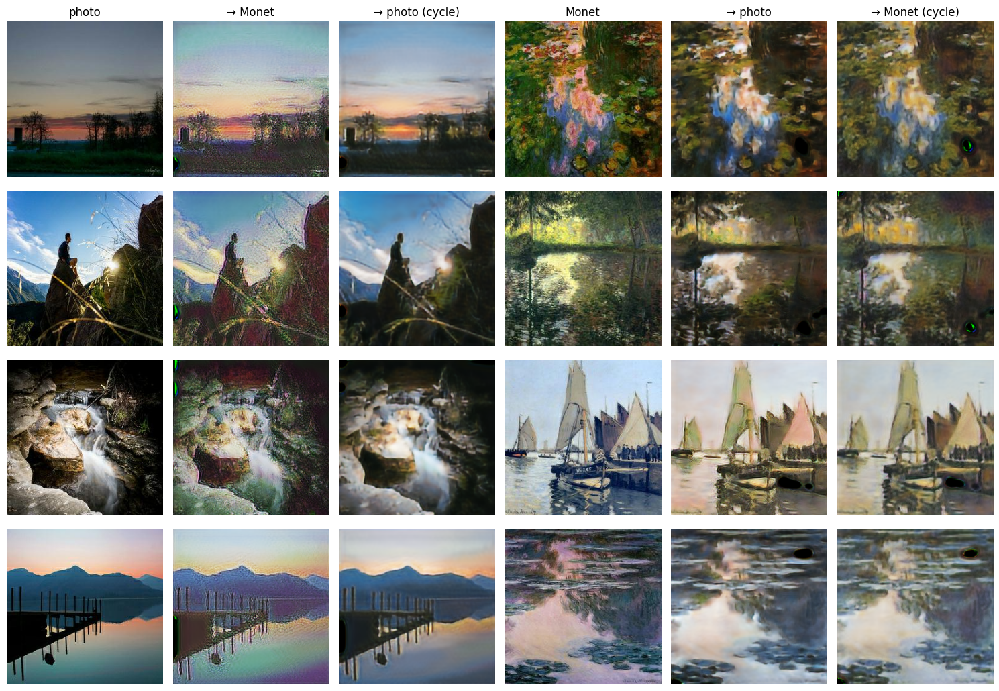

In [8]:
for d in ("cycle_B_photo_monet_photo", "cycle_A_monet_photo_monet"):
    m = E[d]
    print(f"{d}: L1(x, reconstruction) = {m['cycle_l1']['mean']:.4f} | L1(x, translation) = {m['translation_l1']['mean']:.4f} "
          f"| L1(x, unrelated image) = {m['unrelated_l1']['mean']:.4f} | LPIPS(x, recon) = {m['cycle_lpips']['mean']:.3f} "
          f"vs LPIPS(x, translation) = {m['translation_lpips']['mean']:.3f}")
G_AB, G_BA, _ = cg.load_generators(ckpt, CFG, device)
rng = np.random.default_rng(CFG["seed"])
pick_b = [photo[i] for i in rng.choice(len(photo), 4, replace=False)]
pick_a = [monet[i] for i in rng.choice(len(monet), 4, replace=False)]
fig, ax = plt.subplots(4, 6, figsize=(15, 10.5))
with torch.no_grad():
    for r, (pb, pa) in enumerate(zip(pick_b, pick_a)):
        xb = cg.to_tensor(cg.load_image(pb)).unsqueeze(0).to(device); yb = G_BA(xb); rb = G_AB(yb)
        xa = cg.to_tensor(cg.load_image(pa)).unsqueeze(0).to(device); ya = G_AB(xa); ra = G_BA(ya)
        for c, (img, title) in enumerate([(xb, "photo"), (yb, "→ Monet"), (rb, "→ photo (cycle)"),
                                          (xa, "Monet"), (ya, "→ photo"), (ra, "→ Monet (cycle)")]):
            ax[r, c].imshow(cg.to_uint8(img[0])); ax[r, c].axis("off")
            if r == 0: ax[r, c].set_title(title)
fig.tight_layout(); fig.savefig(P["out"] / f"translation_cycle_grid_{TAG}.png", dpi=110); plt.show()

## 3.2 Kaggle submission (`submission.csv`: ID, FID, MiFID)
The values come from the **course-provided `Part3_Evaluation_Script.ipynb`**, run unmodified except for its folder
paths, which the script asks you to set. It compares the first 300 real Monet with the first 300 of my photo→Monet
outputs (`outputs/pred_B2A/`), and the first 300 real photos with my 300 Monet→photo outputs (`outputs/pred_A2B/`).
It then writes the average of the two directions. The executed copy is kept as `src/Part3_Evaluation_Script_run.ipynb`.

In [9]:
import re, shutil, nbformat
official = P["task"] / "Part3_Evaluation_Script.ipynb"
run_nb = P["src"] / f"Part3_Evaluation_Script_run{'_smoke' if SMOKE else ''}.ipynb"
sfx = "" if TAG == "full" else "_smoke"
nb = nbformat.read(official, as_version=4)
for c in nb.cells:
    if c.cell_type == "code" and 'BASE = "Part 3/Data"' in c.source:
        c.source = (c.source.replace('BASE = "Part 3/Data"', 'BASE = "../../data"')
                    .replace('os.path.join(BASE, "pred_A2B")', f'"../outputs/pred_A2B{sfx}"')
                    .replace('os.path.join(BASE, "pred_B2A")', f'"../outputs/pred_B2A{sfx}"'))
        print("path cell after edit:\n" + c.source)
nbformat.write(nb, run_nb)
r = subprocess.run([sys.executable, "-m", "jupyter", "nbconvert", "--to", "notebook", "--execute", "--inplace",
                    "--ExecutePreprocessor.timeout=-1", str(run_nb)], capture_output=True, text=True)
assert r.returncode == 0, r.stderr[-3000:]
done = nbformat.read(run_nb, as_version=4)
for c in done.cells:
    for o in c.get("outputs", []):
        t = o.get("text", "") or o.get("data", {}).get("text/plain", "")
        if "FID" in t or "Counts" in t:
            print(t.strip())
sub_src = P["src"] / "submission.csv"
sub = P["member"] / ("submission.csv" if TAG == "full" else "submission_smoke.csv")
shutil.move(sub_src, sub)
print("\n" + R(sub) + ":\n" + open(sub).read())

path cell after edit:
# Config: set your root
BASE = "../../data"

REAL_MONET = os.path.join(BASE, "monet_jpg")   # real domain A
REAL_PHOTO = os.path.join(BASE, "photo_jpg")   # real domain B
GEN_A2B    = "../outputs/pred_A2B"    # Monet -> Photo #You can modify the patha s per your directory
GEN_B2A    = "../outputs/pred_B2A"    # Photo -> Monet #You can modify the patha s per your directory

# Limit to N images per set
# Set to None to use all images in each folder
N_EVAL = 300

BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Counts (after N_EVAL cap):
Real Monet: 300  | Gen Monet (B2A): 300
Real Photo: 300  | Gen Photo (A2B): 300
[Photo->Monet] FID=129.212  MiFID=0.3975

 Evaluating Monet -> Photo (A2B)
[Monet->Photo] FID=169.756  MiFID=0.4296
ID         FID     MiFID
0   1  149.483711  0.413546

task3_gan/rajesh_paruchuri/submission.csv:
ID,FID,MiFID
1,149.48371141836398,0.41354605555534363



## 3.2 Blinded human audit (30 fixed samples, 2 raters)
The 30 photos are chosen with a fixed seed before any output is inspected. Each audit image is anonymous
(`audit_XX.png`: input on the left, translation on the right) and the order is shuffled. Two raters score style,
content and artifacts (1–5) independently in `outputs/human_audit/audit_sheet.csv`, using `RATER_GUIDE.md`.
Agreement is reported as % exact agreement, % within-1 agreement, and Cohen's kappa (unweighted and linear-weighted).

In [10]:
import human_audit as ha
aud = P["out"] / "human_audit"
if not (aud / "audit_sheet.csv").exists():
    @torch.no_grad()
    def tr(p):
        return cg.to_uint8(G_BA(cg.to_tensor(cg.load_image(p)).unsqueeze(0).to(device))[0])
    picks = ha.make_sheet(photo, tr, aud, CFG["audit_n"], CFG["seed"])
    print("audit sheet created for photo indices:", picks)
HA = ha.score(aud / "audit_sheet.csv")
print(json.dumps(HA, indent=1))

{
 "status": "incomplete: 0/30 rows have both raters' scores"
}


## Metrics report

In [11]:
b2a, a2b = E["photo2monet_B2A"], E["monet2photo_A2B"]
cB, cA = E["cycle_B_photo_monet_photo"], E["cycle_A_monet_photo_monet"]
last = lambda k: float(np.mean(hist[k][-10:]))
rows = [
 ("fid_photo2monet_B2A", b2a["fid"], f"{b2a['n_fake']} translated photos vs {b2a['n_real']} real Monet; torchvision Inception-v3"),
 ("fid_monet2photo_A2B", a2b["fid"], f"{a2b['n_fake']} translated Monet vs {a2b['n_real']} real photos"),
 ("kid_photo2monet_B2A", b2a["kid_mean"], f"std {b2a['kid_std']:.5f}; {CFG['kid_subsets']} subsets of {CFG['kid_subset_size']}"),
 ("kid_monet2photo_A2B", a2b["kid_mean"], f"std {a2b['kid_std']:.5f}"),
 ("precision_photo2monet_B2A", b2a["precision"], "k=3 improved precision"), ("recall_photo2monet_B2A", b2a["recall"], "k=3 improved recall"),
 ("density_photo2monet_B2A", b2a["density"], ""), ("coverage_photo2monet_B2A", b2a["coverage"], ""),
 ("precision_monet2photo_A2B", a2b["precision"], ""), ("recall_monet2photo_A2B", a2b["recall"], ""),
 ("density_monet2photo_A2B", a2b["density"], ""), ("coverage_monet2photo_A2B", a2b["coverage"], ""),
 ("memorisation_cosdist_photo2monet_B2A", b2a["memorisation_min_cosine_distance"], "mean min cosine distance to a real Monet (MiFID-style term, local)"),
 ("cycle_l1_photo_monet_photo_B", cB["cycle_l1"]["mean"], f"pixels in [0,1], {cB['cycle_l1']['n']} photos"),
 ("cycle_l1_monet_photo_monet_A", cA["cycle_l1"]["mean"], f"{cA['cycle_l1']['n']} Monet"),
 ("lpips_cycle_B", cB["cycle_lpips"]["mean"], "LPIPS-VGG input vs reconstruction"), ("lpips_cycle_A", cA["cycle_lpips"]["mean"], ""),
 ("lpips_translation_photo2monet", cB["translation_lpips"]["mean"], "LPIPS-VGG input vs translation"),
 ("lpips_translation_monet2photo", cA["translation_lpips"]["mean"], ""),
 ("content_cosine_photo2monet", cB["content_cosine"]["mean"], "VGG16 relu4_3 cosine, input vs translation"),
 ("content_cosine_monet2photo", cA["content_cosine"]["mean"], ""),
 ("loss_G_adv_final", last("loss_G_adv"), "mean of last 10 log windows"), ("loss_D_A_final", last("loss_D_A"), ""),
 ("loss_D_B_final", last("loss_D_B"), ""), ("loss_cycle_final", last("loss_cycle"), "unweighted L1 sum A+B"),
 ("loss_identity_final", last("loss_identity"), "unweighted L1 sum A+B"),
 ("grad_norm_G_mean", summary["grad_norm_G_mean"], "window means, no clipping"), ("grad_norm_G_max", summary["grad_norm_G_max"], ""),
 ("grad_norm_D_mean", summary["grad_norm_D_mean"], ""), ("grad_norm_D_max", summary["grad_norm_D_max"], ""),
 ("nan_count", summary["nan_count"], "non-finite steps (skipped)"),
 ("param_count_total", summary["params_total"], f"G {summary['params_G_each']:,} x2 + D {summary['params_D_each']:,} x2"),
 ("training_time_sec", summary["total_training_time_sec"], ""), ("train_images_per_sec", summary["images_per_sec"], "Monet+photo crops per second"),
 ("inference_images_per_sec_photo2monet", E["gen_images_per_sec_b2a"], "256x256, batch 8"),
 ("peak_mps_tensor_memory_mb", summary["peak_mps_tensor_memory_mb"], ""), ("peak_mps_driver_memory_mb", summary["peak_mps_driver_memory_mb"], ""),
 ("peak_process_rss_mb", summary["peak_process_rss_mb"], ""),
 ("human_audit_score_1to5", HA.get("overall_human_score_mean_1to5", "pending"), "mean of style/content/artifacts, both raters"),
]
for c in ("style", "content", "artifacts"):
    rows.append((f"human_{c}_cohen_kappa", HA.get(c, {}).get("cohen_kappa", "pending"), "unweighted"))
    rows.append((f"human_{c}_exact_agreement", HA.get(c, {}).get("exact_agreement", "pending"), ""))
sub_vals = list(csv.DictReader(open(P["member"] / "submission.csv")))[0] if (P["member"] / "submission.csv").exists() else {}
done_nb = nbformat.read(P["src"] / "Part3_Evaluation_Script_run.ipynb", as_version=4)
per_dir = re.findall(r"\[(Photo->Monet|Monet->Photo)\] FID=([0-9.]+)  MiFID=([0-9.]+)",
                     "".join(o.get("text", "") for c in done_nb.cells for o in c.get("outputs", [])))
for d, f_, m_ in per_dir:
    key = "photo2monet_B2A" if d.startswith("Photo") else "monet2photo_A2B"
    rows += [(f"official_script_fid_{key}", float(f_), "Part3_Evaluation_Script.ipynb, first 300 vs 300"),
             (f"official_script_mifid_{key}", float(m_), "script's MiFID = mean paired cosine distance")]
rows += [("kaggle_submission_fid", float(sub_vals.get("FID", "nan")), "submission.csv = mean of both directions (official script)"),
         ("kaggle_submission_mifid", float(sub_vals.get("MiFID", "nan")), "submission.csv"),
         ]
kr_path = P["out"] / "kaggle_result.json"   # written after the Kaggle upload
kr = json.load(open(kr_path)) if kr_path.exists() else {}
rows += [("kaggle_public_score", kr.get("public_score", "pending"), f"my submission ref {kr.get('submission_ref', '-')}, team {kr.get('team', '-')}"),
         ("kaggle_private_score", kr.get("private_score") or "not shown until the competition closes", ""),
         ("kaggle_rank", kr.get("team_public_rank", "pending"), "team public rank (Kaggle ranks a team by its best submission)"),
         ("hardware", cg.hardware_string(device), "")]
csv_path = P["member"] / "metrics_report.csv" if not SMOKE else P["out"] / "metrics_report_smoke.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f); w.writerow(["metric", "value", "notes"]); w.writerows(rows)
print("saved", R(csv_path))

saved task3_gan/rajesh_paruchuri/metrics_report.csv
